# 00｜一键体验：先看 CNN 怎样识别手写数字

本页不要求先理解卷积公式。运行后先观察 Loss、Accuracy、混淆矩阵、错误样本和 Feature maps。

**操作：**选择课程 Python 内核并点击 `Run All`。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "cnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "02_cnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from cnn_lab import quick_demo

## 点击一次，完成数据到预测的完整流程

共享服务器默认使用 CPU。只有获得课堂分配后，才把 `DEVICE` 改为 `cuda:x`，并用指定的 GPU 编号替换 `x`。

**预测问题：**模型最终输出的是一张新图片，还是 10 个类别分数？

<details><summary>参考答案</summary>
CNN 的分类头输出 10 个 logits，每个位置对应数字 0–9。Softmax 可以把它们转换为总和为 1 的类别概率。
</details>


CNN 配置对比
------------------------------------------------------------------------------
配置                           测试准确率       右移准确率         参数量       耗时(秒)
------------------------------------------------------------------------------
CNN｜通道 8→16｜max pooling      96.7%      65.6%       3,818        0.36
------------------------------------------------------------------------------


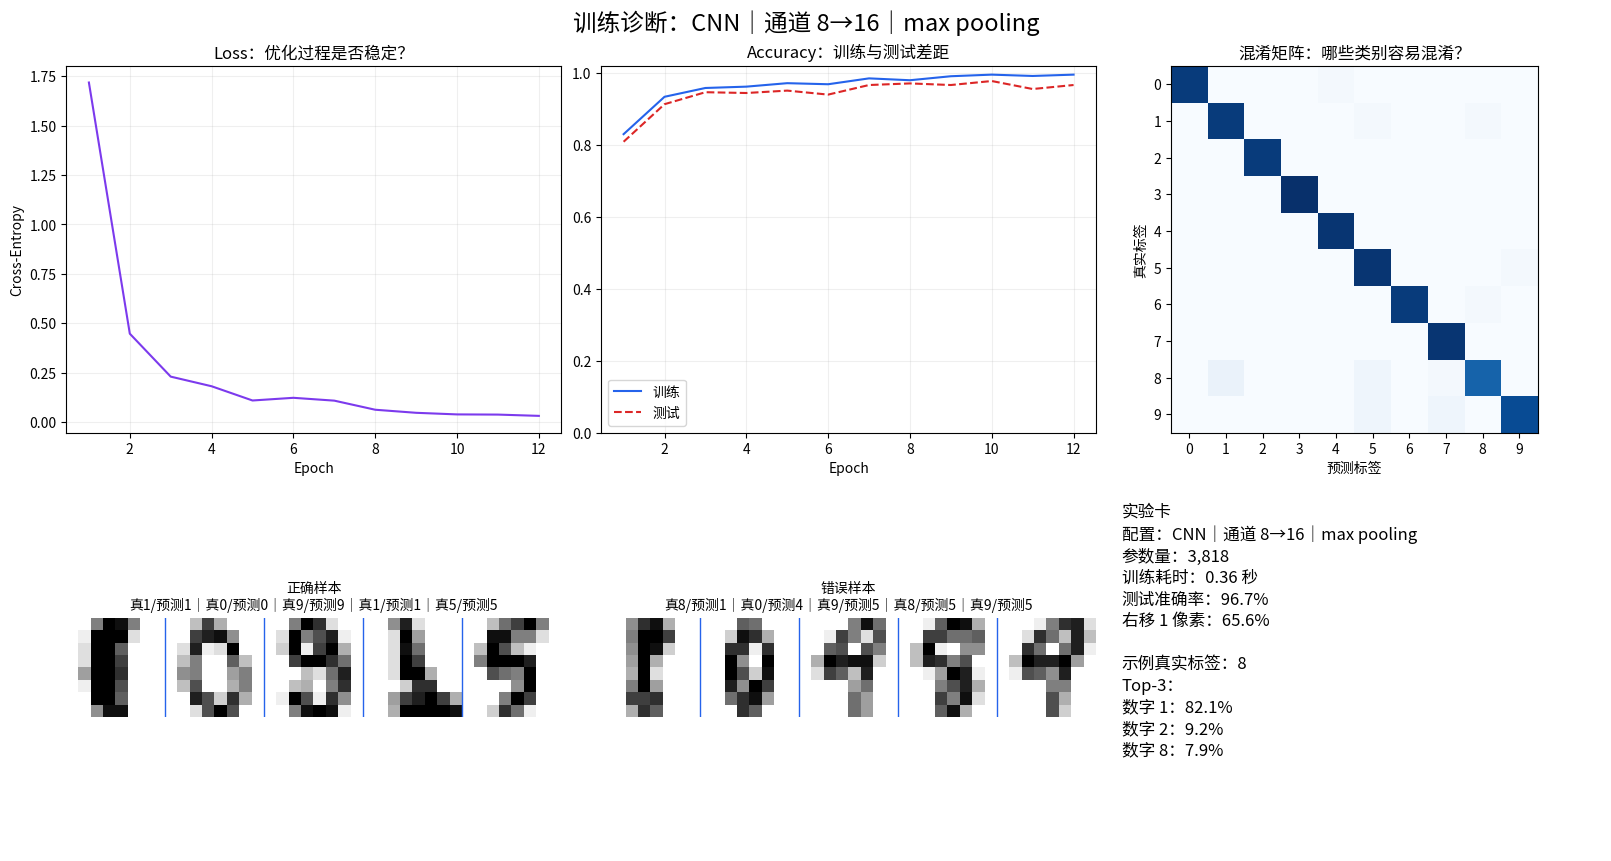

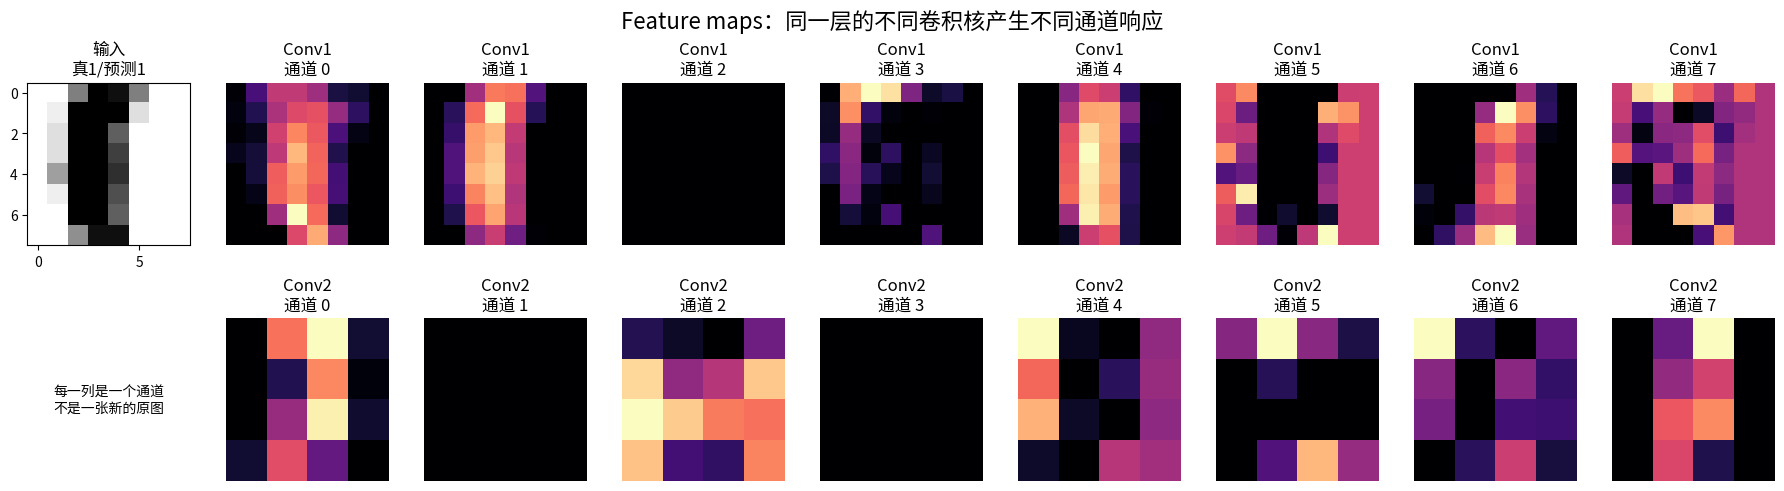

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

result = quick_demo(epochs=12, device=DEVICE, show_features=True)

## 看图顺序

1. Loss 是否总体下降？
2. 训练与测试 Accuracy 是否同步变化？
3. 混淆矩阵的对角线是否更亮？
4. 错误样本是否模糊或容易与另一数字混淆？
5. 同一层不同 Feature map 为什么不完全相同？

本次结果只说明当前数据划分、模型和随机种子下的现象，不把一次 Accuracy 写成固定答案。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [3]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}